In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

In [7]:
df = pd.read_csv("final_macro_dataset_date.csv")
df.head()

,Year,Quarter,Date,Unemployment,GDP,CPI,InterestRate,Exports
0,1999,Q1,1999-01-01,6.266667,37412,69.87321,3.000000,5.030607e+06
1,1999,Q2,1999-04-01,6.000000,38083,70.75871,2.543956,5.341812e+06
2,1999,Q3,1999-07-01,5.433333,40112,71.12095,2.500000,5.832836e+06
3,1999,Q4,1999-10-01,5.300000,40871,71.84544,2.809783,6.118408e+06
4,2000,Q1,2000-01-01,4.800000,40867,72.89193,3.197802,6.108333e+06


In [8]:
print(df.shape)
print(df.isna().sum())
print(df.describe())

(104, 8)
Year            0
Quarter         0
Date            0
Unemployment    0
GDP             0
CPI             0
InterestRate    0
Exports         0
dtype: int64
             Year  Unemployment            GDP         CPI  InterestRate  \
count   104.00000    104.000000     104.000000  104.000000    104.000000   
mean   2011.50000      7.487179   74559.913462   96.479329      1.929166   
std       7.53632      3.882204   30152.910612   11.796405      1.716467   
min    1999.00000      3.900000   37412.000000   69.873210      0.000000   
25%    2005.00000      4.691667   54601.000000   89.293625      0.047802   
50%    2011.50000      5.333333   59253.500000   99.577380      1.262049   
75%    2018.00000      9.666667   95855.250000  100.966025      3.781250   
max    2024.00000     15.933333  142896.000000  122.278100      4.500000   

            Exports  
count  1.040000e+02  
mean   9.643755e+06  
std    3.553353e+06  
min    5.030607e+06  
25%    7.304675e+06  
50%    7.822317e+

In [9]:
df = df.sort_values(["Year", "Quarter"])
print(df.head(10))
print(df.tail(10))

   Year Quarter        Date  Unemployment    GDP       CPI  InterestRate  \
0  1999      Q1  1999-01-01      6.266667  37412  69.87321      3.000000   
1  1999      Q2  1999-04-01      6.000000  38083  70.75871      2.543956   
2  1999      Q3  1999-07-01      5.433333  40112  71.12095      2.500000   
3  1999      Q4  1999-10-01      5.300000  40871  71.84544      2.809783   
4  2000      Q1  2000-01-01      4.800000  40867  72.89193      3.197802   
5  2000      Q2  2000-04-01      4.600000  42233  74.46166      3.781250   
6  2000      Q3  2000-07-01      4.233333  43730  75.50815      3.781250   
7  2000      Q4  2000-10-01      3.900000  44364  76.55464      3.781250   
8  2001      Q1  2001-01-01      3.966667  43987  76.75589      3.781250   
9  2001      Q2  2001-04-01      4.000000  44926  78.48662      3.781250   

        Exports  
0  5.030607e+06  
1  5.341812e+06  
2  5.832836e+06  
3  6.118408e+06  
4  6.108333e+06  
5  6.687900e+06  
6  7.118233e+06  
7  8.000500e+06  
8

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

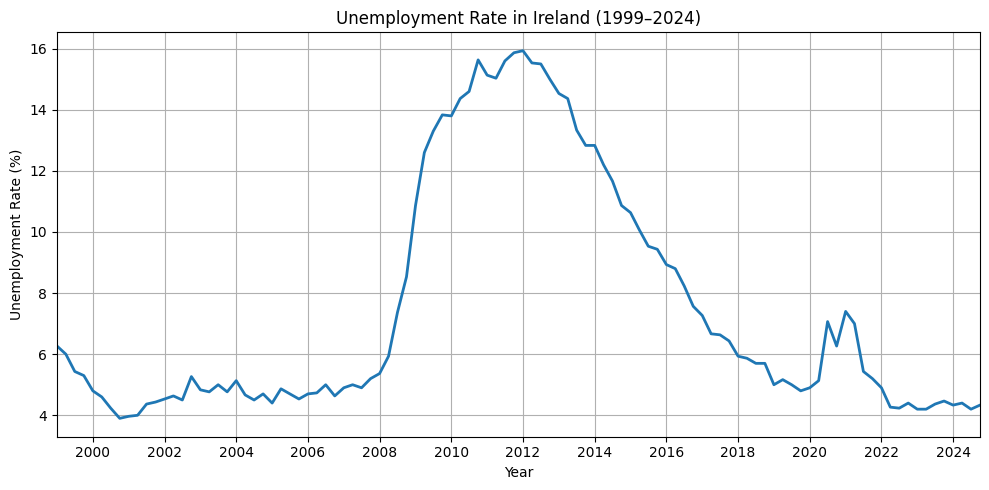

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Unemployment"], linewidth=2)
plt.title("Unemployment Rate in Ireland (1999–2024)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.xlim(df["Date"].min(), df["Date"].max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("unemployment_rate.png", dpi=300)

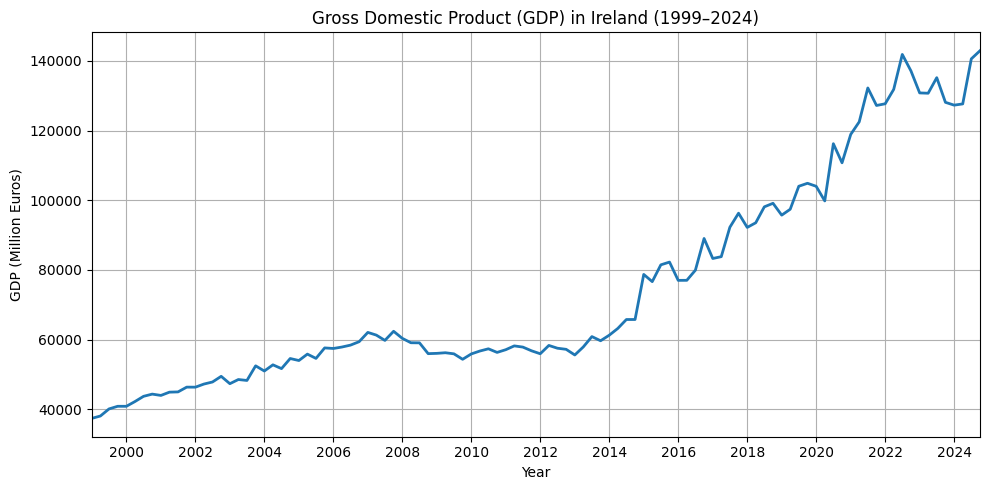

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["GDP"], linewidth=2)
plt.title("Gross Domestic Product (GDP) in Ireland (1999–2024)")
plt.xlabel("Year")
plt.ylabel("GDP (Million Euros)")
plt.xlim(df["Date"].min(), df["Date"].max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("GDP.png", dpi=300)

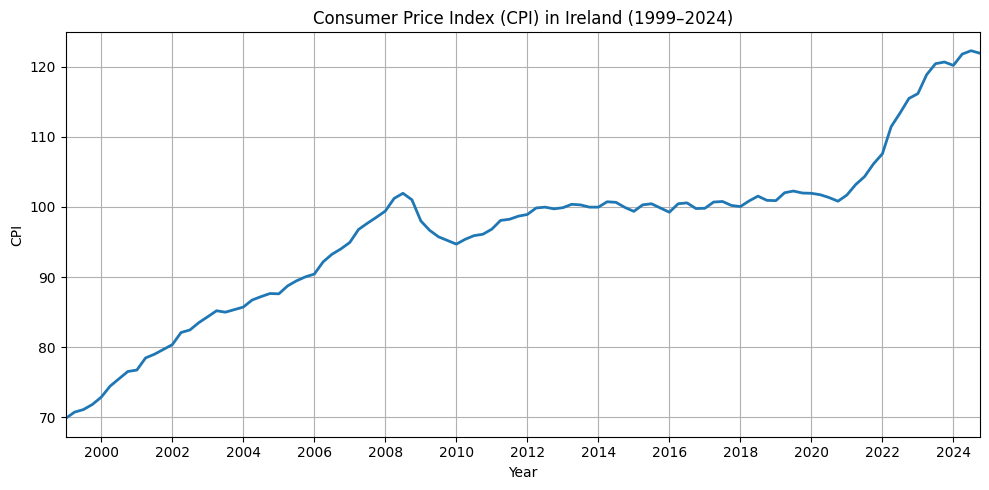

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["CPI"], linewidth=2)
plt.title("Consumer Price Index (CPI) in Ireland (1999–2024)")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.xlim(df["Date"].min(), df["Date"].max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("CPI.png", dpi=300)

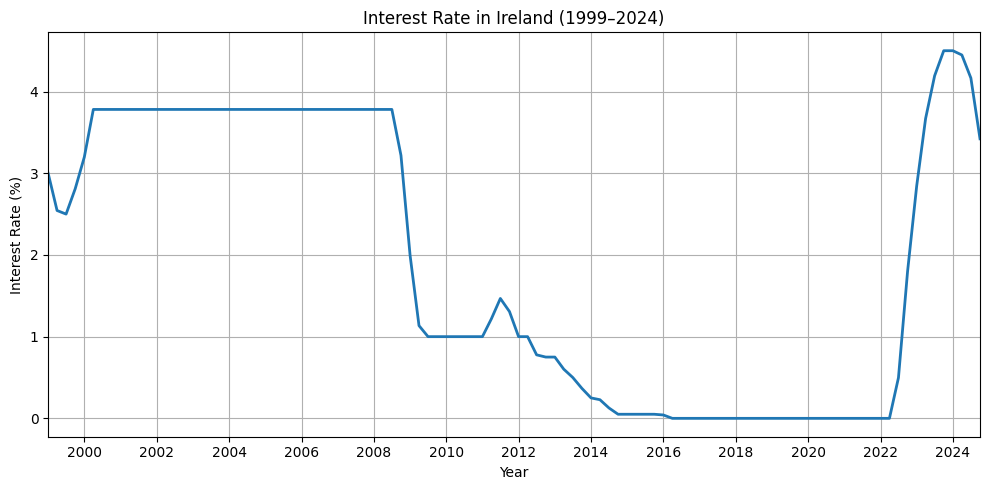

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["InterestRate"], linewidth=2)
plt.title("Interest Rate in Ireland (1999–2024)")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.xlim(df["Date"].min(), df["Date"].max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("interest_rate.png", dpi=300)

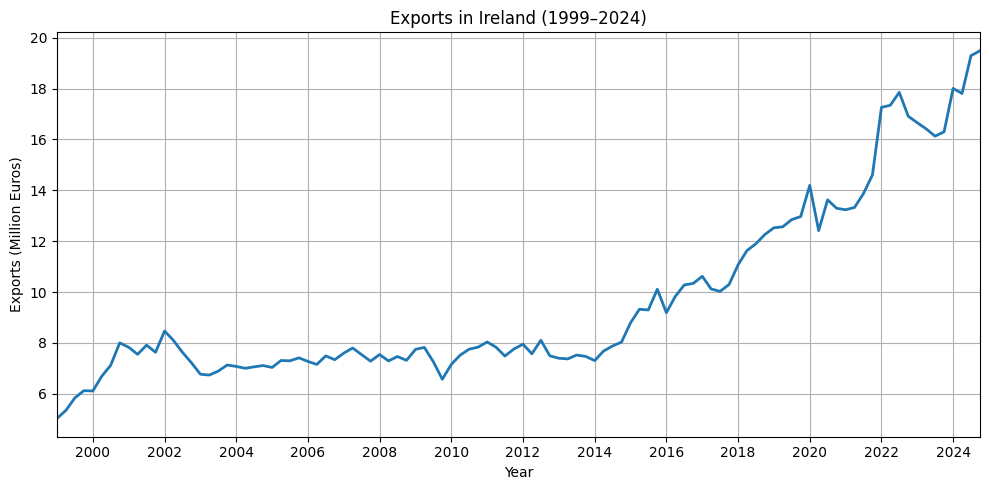

<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Exports"] / 1_000_000, linewidth=2)
plt.title("Exports in Ireland (1999–2024)")
plt.xlabel("Year")
plt.ylabel("Exports (Million Euros)")
plt.xlim(df["Date"].min(), df["Date"].max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("exports.png", dpi=300)

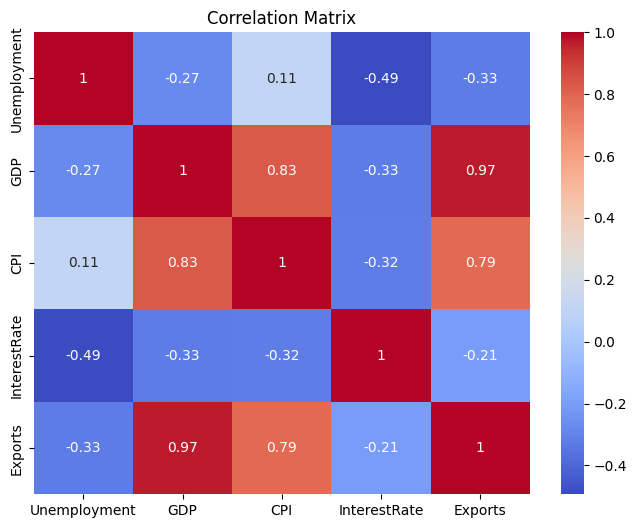

In [16]:
corr = df[["Unemployment", "GDP", "CPI", "InterestRate", "Exports"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

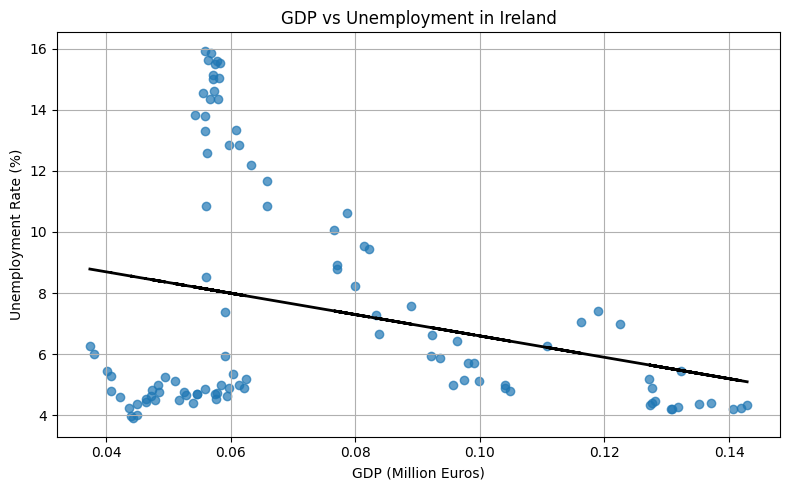

In [18]:
x = df["GDP"] / 1_000_000
y = df["Unemployment"]

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.7)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), linestyle="-", color="black", linewidth=2)
plt.title("GDP vs Unemployment in Ireland")
plt.xlabel("GDP (Million Euros)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

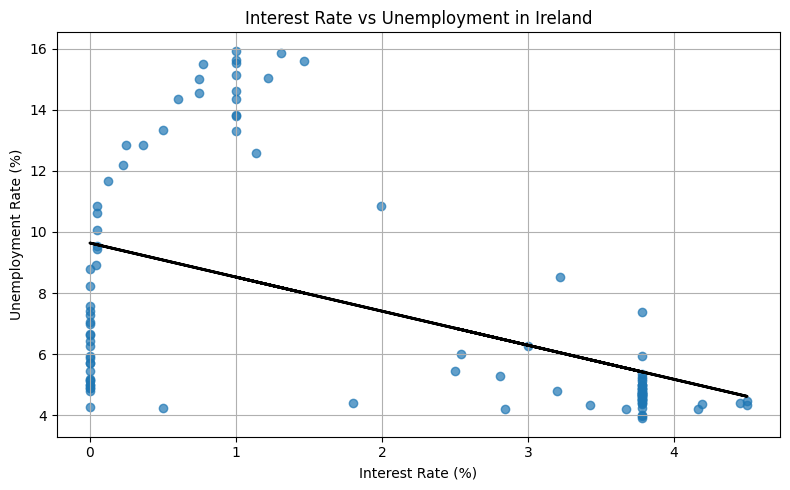

In [20]:
x = df["InterestRate"]
y = df["Unemployment"]

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.7)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), linestyle="-", color="black", linewidth=2)
plt.title("Interest Rate vs Unemployment in Ireland")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

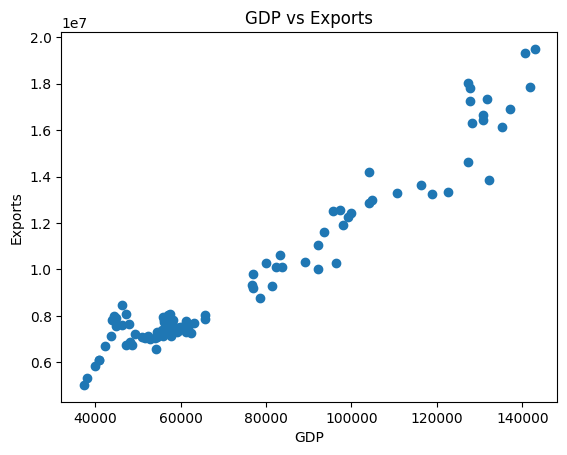

In [21]:
plt.scatter(df["GDP"], df["Exports"])
plt.title("GDP vs Exports")
plt.xlabel("GDP")
plt.ylabel("Exports")
plt.show()

In [22]:
df = df.sort_values(["Year", "Quarter"]).reset_index(drop=True)
df["Unemp_lag1"] = df["Unemployment"].shift(1)
df["GDP_lag1"] = df["GDP"].shift(1)
df["CPI_lag1"] = df["CPI"].shift(1)
df["Exports_lag1"] = df["Exports"].shift(1)
df["Rate_lag1"] = df["InterestRate"].shift(1)
df_model = df.dropna()

In [23]:
X = df_model[["Unemp_lag1", "GDP_lag1", "CPI_lag1", "Exports_lag1", "Rate_lag1"]]
y = df_model["Unemployment"]

In [24]:
split = int(len(df_model) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.038112497205477


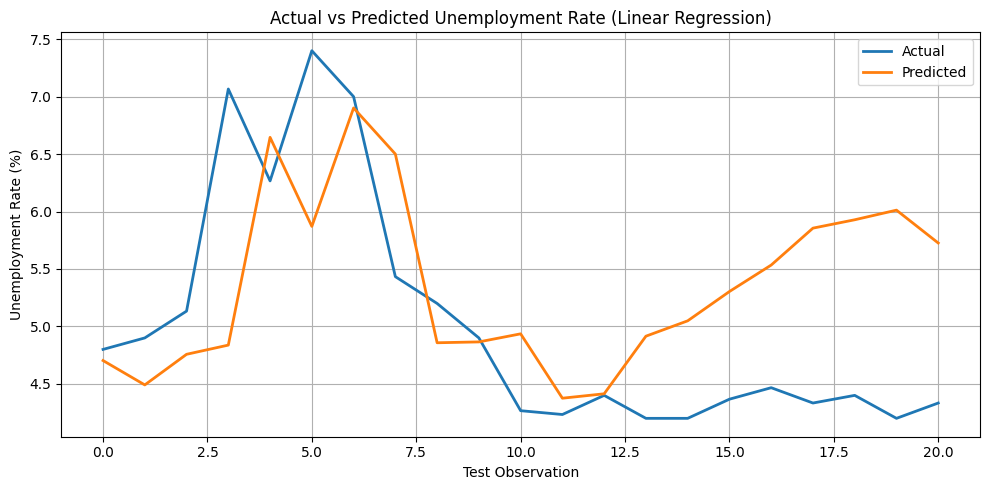

In [29]:
plt.figure(figsize=(10,5))

plt.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Unemployment Rate (Linear Regression)")
plt.xlabel("Test Observation")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("prediction_vs_actual.png", dpi=300)

plt.show()

In [30]:
for lag in [1, 2, 3, 4]:
    df[f"Unemp_lag{lag}"] = df["Unemployment"].shift(lag)
    df[f"GDP_lag{lag}"] = df["GDP"].shift(lag)
    df[f"CPI_lag{lag}"] = df["CPI"].shift(lag)
    df[f"Exports_lag{lag}"] = df["Exports"].shift(lag)
    df[f"Rate_lag{lag}"] = df["InterestRate"].shift(lag)

df_model = df.dropna()

In [31]:
X = df_model.drop(columns=["Date", "Unemployment", "Year", "Quarter"])
y = df_model["Unemployment"]

In [32]:
split = int(len(df_model) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [33]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("New RMSE:", rmse)

New RMSE: 0.7484161527278201


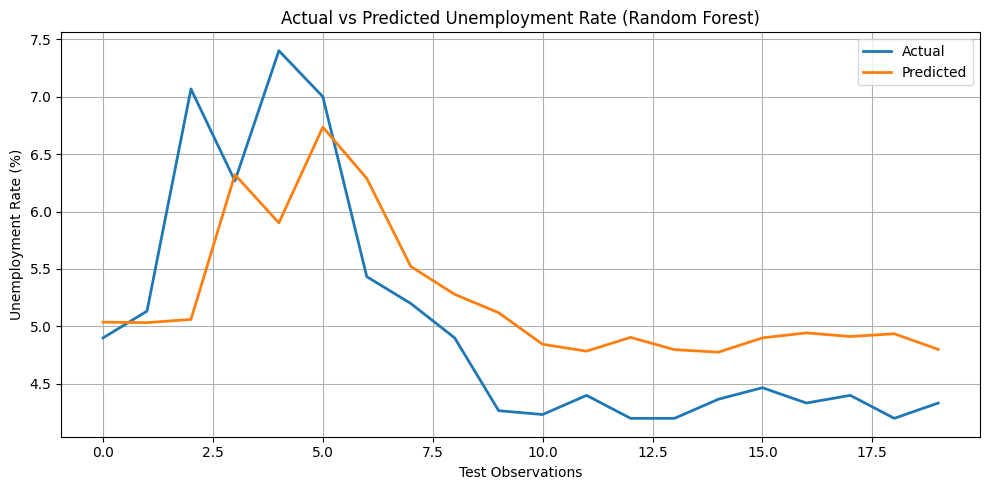

In [36]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Unemployment Rate (Random Forest)")
plt.xlabel("Test Observations")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=300)
plt.show()

In [37]:
df["GDP_growth"] = df["GDP"].pct_change()
df["Inflation"] = df["CPI"].pct_change()
df["Exports_growth"] = df["Exports"].pct_change()

In [38]:
for lag in [1, 2, 3, 4]:
    df[f"GDPg_lag{lag}"] = df["GDP_growth"].shift(lag)
    df[f"Infl_lag{lag}"] = df["Inflation"].shift(lag)
    df[f"Expg_lag{lag}"] = df["Exports_growth"].shift(lag)

In [39]:
df_model = df.dropna()

X = df_model.drop(columns=["Date", "Unemployment", "Year", "Quarter"])
y = df_model["Unemployment"]

In [40]:
split = int(len(df_model) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [41]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("New RMSE:", rmse)

New RMSE: 0.7786544508996741


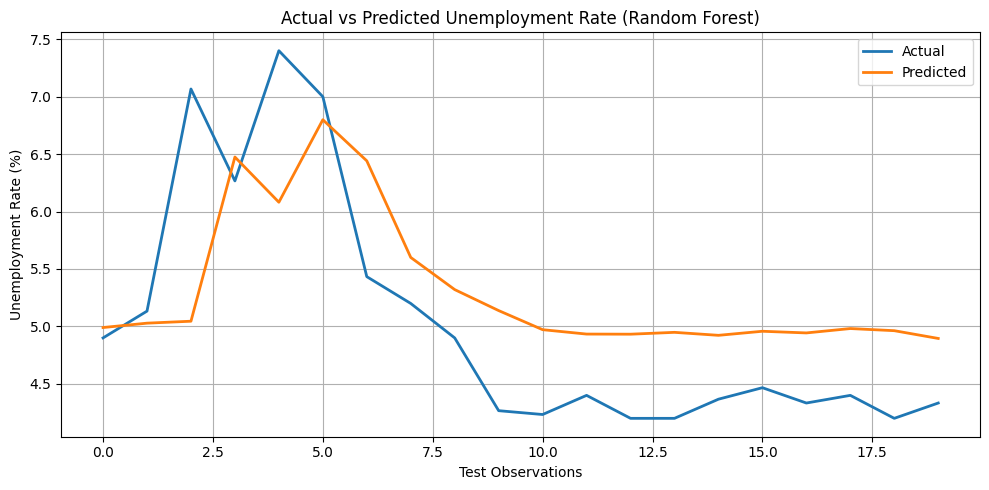

In [44]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Unemployment Rate (Random Forest)")
plt.xlabel("Test Observations")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=300)
plt.show()

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [46]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("New RMSE:", rmse)

New RMSE: 0.7315456593857995


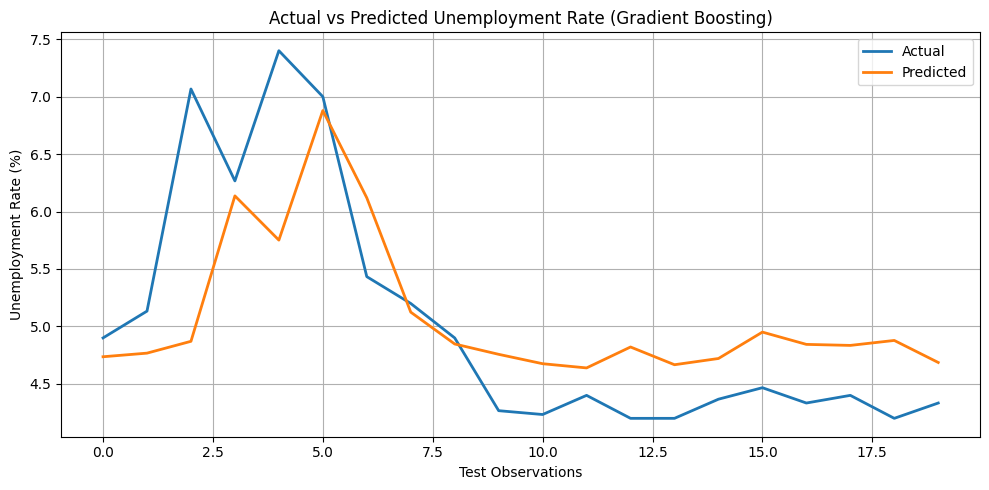

In [48]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Unemployment Rate (Gradient Boosting)")
plt.xlabel("Test Observations")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=300)
plt.show()

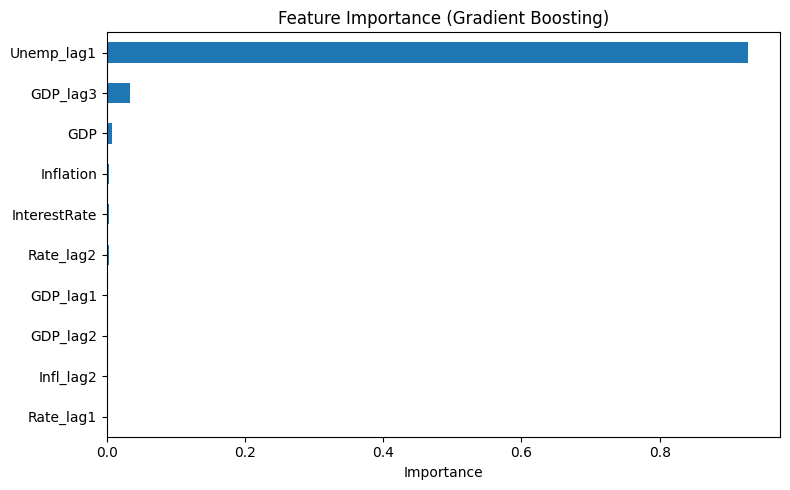

In [49]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,5))
feat_imp.tail(10).plot(kind="barh")
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=300)
plt.show()

In [50]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Unemp_lag1,0.927648
GDP_lag3,0.034103
GDP,0.007026
Inflation,0.002798
InterestRate,0.002718
Rate_lag2,0.002635
GDP_lag1,0.002552
GDP_lag2,0.002503
Infl_lag2,0.002498
Rate_lag1,0.002436


In [51]:
X = df_model.drop(columns=["Date", "Unemployment", "Year", "Quarter", "Unemp_lag1"])
y = df_model["Unemployment"]

In [52]:
split = int(len(df_model) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [54]:
y_pred = model.predict(X_test)

In [55]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE without lag1:", rmse)

RMSE without lag1: 0.9598621735864967


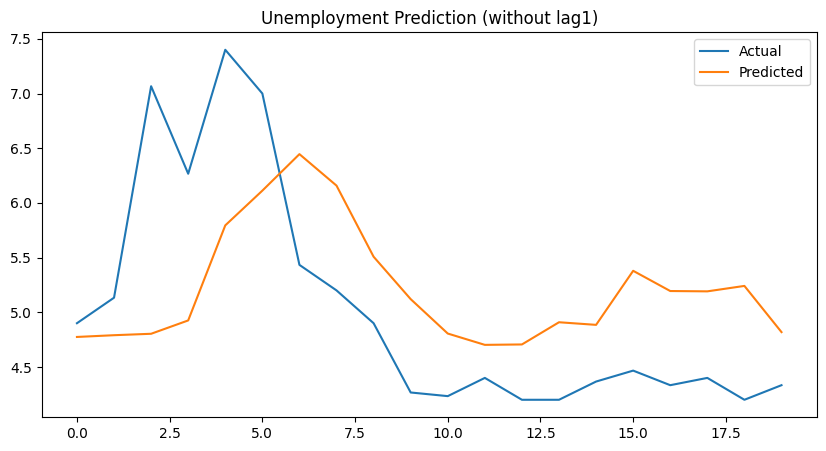

In [56]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Unemployment Prediction (without lag1)")
plt.show()

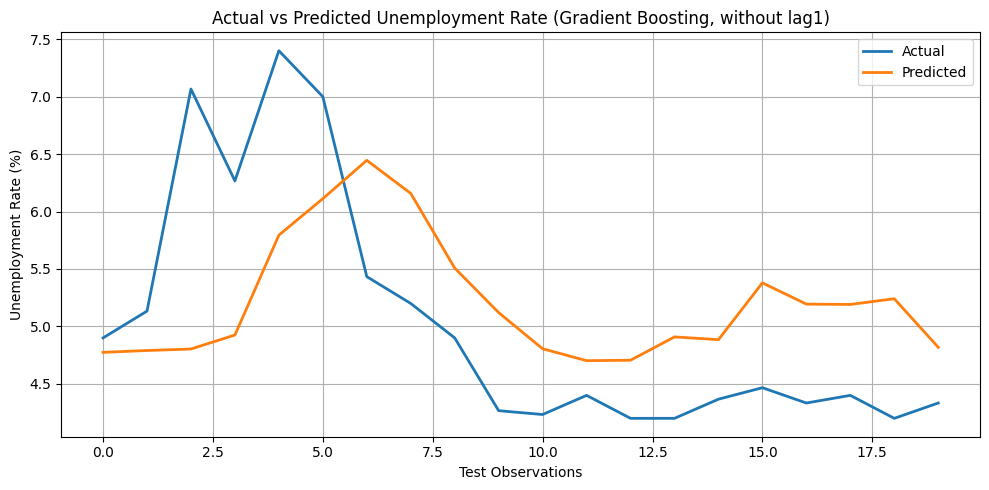

In [57]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Unemployment Rate (Gradient Boosting, without lag1)")
plt.xlabel("Test Observations")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=300)
plt.show()

In [58]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Unemp_lag2,0.881076
GDP_lag1,0.024569
GDP_lag3,0.015570
Inflation,0.014795
GDP,0.009048
Rate_lag1,0.007479
GDP_lag2,0.005316
InterestRate,0.004810
Rate_lag3,0.004583
Rate_lag2,0.004347


In [59]:
X = df_model.drop(columns=["Date", "Unemployment", "Year", "Quarter", "Unemp_lag1", "Unemp_lag2", "Unemp_lag3", "Unemp_lag4"])

In [60]:
split = int(len(df_model) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [62]:
y_pred = model.predict(X_test)

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE without lags:", rmse)

RMSE without lags: 1.6843965686069338


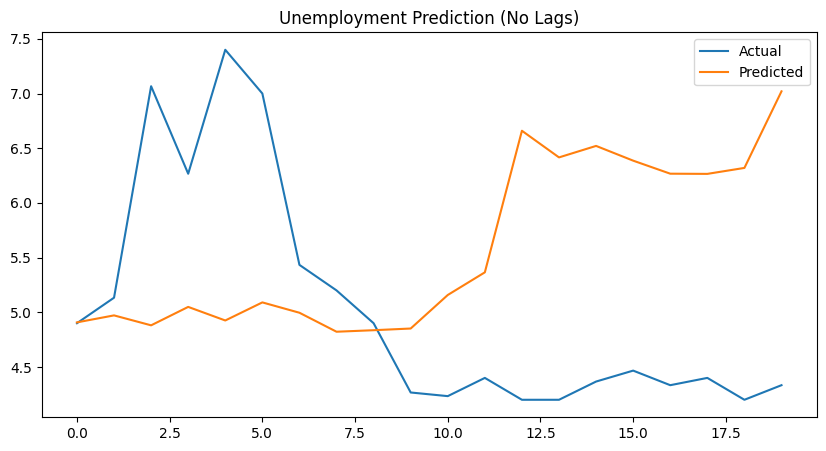

In [64]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Unemployment Prediction (No Lags)")
plt.show()

In [65]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
InterestRate,0.524827
GDP_lag4,0.324550
GDP_lag2,0.020795
CPI_lag4,0.016415
Rate_lag3,0.015102
Rate_lag2,0.015060
Exports_lag4,0.014854
GDP_lag3,0.014652
Rate_lag4,0.011976
Exports_lag3,0.008426
